In [1]:
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display
from langchain_core.tools import tool 
import os

c:\python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# set LANGSMITH_API_KEY  to langsmith key 
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "langsmith-demo"

In [3]:
llm = init_chat_model("gemini-2.5-flash", model_provider="google_genai")

In [4]:
# Create Tools
@tool()
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

@tool()
def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

In [5]:
# Create LLM that can call tools 
tools = [add, divide]
llm_with_tools = llm.bind_tools(tools)

In [6]:
sys_msg = SystemMessage(content="Either use tools to perform arithmetic on a set of inputs or just give me answer with your knowledge")
# Node to call LLM
def tool_calling_llm(state: MessagesState) -> MessagesState:
   response_messages = llm_with_tools.invoke([sys_msg] + state["messages"])
   return {"messages": [response_messages]}



In [7]:
# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))   # Node to call tools


In [8]:
# Define edges: these determine how the control flow moves
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
react_graph = builder.compile()

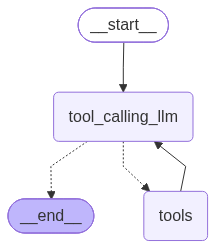

In [9]:
display(Image(react_graph.get_graph().draw_mermaid_png()))

In [10]:
init_messages = [HumanMessage(content="Add 343433 and 4232323 then divide the result by 10")]
response_state = react_graph.invoke({"messages": init_messages})
for m in response_state['messages']:
     m.pretty_print()

================================ Human Message =================================

Add 343433 and 4232323 then divide the result by 10
================================== Ai Message ==================================
Tool Calls:
  add (ff5b552f-6b20-4f77-a32d-56fe4ce27fb4)
 Call ID: ff5b552f-6b20-4f77-a32d-56fe4ce27fb4
  Args:
    a: 343433
    b: 4232323
================================= Tool Message =================================
Name: add

4575756
================================== Ai Message ==================================
Tool Calls:
  divide (94723ec0-c857-49fa-a13e-810a61cfc48e)
 Call ID: 94723ec0-c857-49fa-a13e-810a61cfc48e
  Args:
    a: 4575756
    b: 10
================================= Tool Message =================================
Name: divide

457575.6
================================== Ai Message ==================================

[{'type': 'text', 'text': 'The answer is 457575.6', 'extras': {'signature': 'CpMBARFNMg8P/UkDr2BIy/4zU0Mq5m5Oul7MkKhQqHC9+NBAFsXL+b3Cpioa